# Logistic

# dataroad

In [45]:
import pandas as pd



df = pd.read_csv('dataset/heart_preprocessed.csv')
print(df.shape,end= '\n\n')
df.head()
# PhysicalHealth는 회귀 계수 값 기반으로 제거
X = df.drop(['HeartDisease','PhysicalHealth'], axis=1)
y = df['HeartDisease']
print(X.shape, y.shape)



(319795, 22)

(319795, 20) (319795,)


# basemodel

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from utils import evaluate_scores
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("분리 후 데이터셋 shape")
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

scaler = StandardScaler()

num_cols = ['BMI','MentalHealth',"SleepTime"]

# 스케일링
scaler = StandardScaler()
x_train_scaled[num_cols] = scaler.fit_transform(x_train_scaled[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test_scaled[num_cols])


# -------------------------------
# 2️⃣ 모델 학습 및 예측
# -------------------------------
model = LogisticRegression(max_iter=3000, random_state=42)
model.fit(x_train_scaled, y_train)
#  예측 결과
y_test_pred = model.predict(x_test_scaled)


print("=== Evaluation train Metrics ===")
evaluate_scores(y_train, model.predict(x_train_scaled))
print("\n=== Evaluation test Metrics ===")
evaluate_scores(y_test, y_test_pred)



y_test_prob = model.predict_proba(x_test_scaled)[:, 1]

pr_auc = average_precision_score(y_test, y_test_prob)
print(f"PR-AUC: {pr_auc:.4f}")


분리 후 데이터셋 shape
(255836, 20) (255836,)
(63959, 20) (63959,)
=== Evaluation train Metrics ===
Accuracy  : 0.9158
Precision : 0.5400
Recall    : 0.1107
F1 Score  : 0.1837
ROC AUC   : 0.5509

=== Evaluation test Metrics ===
Accuracy  : 0.9162
Precision : 0.5535
Recall    : 0.1114
F1 Score  : 0.1855
ROC AUC   : 0.5515
PR-AUC: 0.3489


# c 튜닝
+ class_weight 적용
+ 튜닝결과 기본 파리미터가 최적의 파라미터

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from utils import evaluate_scores


# -------------------------------
# 3) C 값만 튜닝할 로지스틱 회귀
# -------------------------------
base_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# train 데이터에서만 튜닝
grid.fit(x_train_scaled, y_train)

print("=== Best Params ===")
print(grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

# -------------------------------
# 4) 최적 모델
# -------------------------------
best_model = grid.best_estimator_

# 예측
y_train_pred = best_model.predict(x_train_scaled)
y_test_pred = best_model.predict(x_test_scaled)

# -------------------------------
# 5) 평가
# -------------------------------
print("\n=== Evaluation train Metrics ===")
evaluate_scores(y_train, y_train_pred)

print("\n=== Evaluation test Metrics ===")
evaluate_scores(y_test, y_test_pred)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Best Params ===
{'C': 1}
Best CV F1: 0.3499

=== Evaluation train Metrics ===
Accuracy  : 0.7512
Precision : 0.2253
Recall    : 0.7819
F1 Score  : 0.3498
ROC AUC   : 0.7651

=== Evaluation test Metrics ===
Accuracy  : 0.7499
Precision : 0.2232
Recall    : 0.7748
F1 Score  : 0.3466
ROC AUC   : 0.7612


# 회귀계수 안정성 확보
+ No scaler
+ PhysicalHealth 제거

In [49]:
import statsmodels.api as sm

x_train_const = sm.add_constant(x_train)  # 타깃 제외

model = sm.Logit(y_train, x_train_const)
result = model.fit()

# -------------------------------
# 4) 결과 출력
# -------------------------------
print(result.summary())


# Race에서 계수가 안정적이지 않은 범주가 존재하지만, 제거하지않음. 설명가능력 때문에

Optimization terminated successfully.
         Current function value: 0.226893
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:               255836
Model:                          Logit   Df Residuals:                   255815
Method:                           MLE   Df Model:                           20
Date:                    토, 21 3 2026   Pseudo R-squ.:                  0.2236
Time:                        20:36:08   Log-Likelihood:                -58047.
converged:                       True   LL-Null:                       -74761.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -4.3818      0.069 

# 성능 전용 모델 학습

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# =========================================
# 0) 데이터 분리
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# 여기서는 threshold 선택 용으로 사용
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # train 60%, calib 20%, test 20%
    stratify=y_train_full,
    random_state=42
)

# =========================================
# 1) 스케일링 대상 변수
# =========================================
scale_cols = ['BMI', 'MentalHealth', 'SleepTime', 'AgeCategory', 'GenHealth']

preprocess = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), scale_cols)
    ],
    remainder='passthrough'
)

# =========================================
# 2) 성능용 모델
# =========================================
perf_model = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        solver='liblinear',
        random_state=42
    ))
])

perf_model.fit(X_train, y_train)

# =========================================
# 3) calib set에서 threshold 선택
#    규칙:
#    - recall >= 0.70
#    - 그중 F1 최대
# =========================================
TARGET_RECALL = 0.70

calib_prob_raw = perf_model.predict_proba(X_calib)[:, 1]

thresholds = np.arange(0.01, 1.00, 0.01)
rows = []

for th in thresholds:
    pred = (calib_prob_raw >= th).astype(int)
    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_calib, pred),
        "precision": precision_score(y_calib, pred, zero_division=0),
        "recall": recall_score(y_calib, pred, zero_division=0),
        "f1": f1_score(y_calib, pred, zero_division=0),
        "pred_pos_rate": pred.mean()
    })

th_df = pd.DataFrame(rows)

cand_df = th_df[th_df["recall"] >= TARGET_RECALL].copy()

if len(cand_df) > 0:
    best_row = cand_df.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False]
    ).iloc[0]
    rule_msg = f"recall >= {TARGET_RECALL:.2f} 조건에서 F1 최대"
else:
    best_recall = th_df["recall"].max()
    fallback_df = th_df[th_df["recall"] == best_recall].copy()
    best_row = fallback_df.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False]
    ).iloc[0]
    rule_msg = (
        f"recall >= {TARGET_RECALL:.2f} 만족 threshold 없음 -> "
        f"최대 recall({best_recall:.4f}) 후보 중 F1 최대"
    )

best_th = float(best_row["threshold"])

print("=== Threshold Selection on CALIB ===")
print("Rule:", rule_msg)
print(best_row)

print("\n=== Top threshold candidates on CALIB ===")
if len(cand_df) > 0:
    print(cand_df.sort_values(["f1", "precision"], ascending=False).head(10))
else:
    print(th_df.sort_values(["recall", "f1"], ascending=False).head(10))

# =========================================
# 4) TEST 평가
# =========================================
test_prob_raw = perf_model.predict_proba(X_test)[:, 1]
test_pred_perf = (test_prob_raw >= best_th).astype(int)

print("\n=== Performance model on TEST ===")
print(f"Threshold : {best_th:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, test_pred_perf):.4f}")
print(f"Precision : {precision_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, test_prob_raw):.4f}")
print(f"PR AUC    : {average_precision_score(y_test, test_prob_raw):.4f}")

# =========================================
# 5) 예측 결과 저장
# =========================================
perf_result_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "perf_prob_raw": test_prob_raw,
    "perf_pred": test_pred_perf
})

print("\n=== Performance result sample ===")
print(perf_result_df.head(10))

=== Threshold Selection on CALIB ===
Rule: recall >= 0.70 조건에서 F1 최대
threshold        0.570000
accuracy         0.797183
precision        0.252933
recall           0.701133
f1               0.371755
pred_pos_rate    0.237246
Name: 56, dtype: float64

=== Top threshold candidates on CALIB ===
    threshold  accuracy  precision    recall        f1  pred_pos_rate
56       0.57  0.797183   0.252933  0.701133  0.371755       0.237246
55       0.56  0.790647   0.248475  0.714286  0.368694       0.246033
54       0.55  0.784565   0.244572  0.726343  0.365929       0.254178
53       0.54  0.778483   0.240229  0.734381  0.362032       0.261636
52       0.53  0.772792   0.236900  0.744976  0.359485       0.269141
51       0.52  0.766772   0.233384  0.755024  0.356554       0.276881
50       0.51  0.759831   0.229583  0.766715  0.353357       0.285824
49       0.50  0.752982   0.226229  0.779320  0.350664       0.294830
48       0.49  0.745368   0.222057  0.789003  0.346574       0.304101
47     

# Calibration 및 해석모델

=== Coefficient Table (sorted by abs_coef) ===
                                feature      coef  odds_ratio  abs_coef
3                                Stroke  1.233700    3.433911  1.233700
6                                   Sex  0.750854    2.118809  0.750854
13                        KidneyDisease  0.650503    1.916505  0.650503
10                            GenHealth -0.537459    0.584231  0.537459
8                              Diabetic  0.513805    1.671640  0.513805
16                           Race_Asian -0.511041    0.599871  0.511041
1                               Smoking  0.369397    1.446862  0.369397
12                               Asthma  0.323848    1.382437  0.323848
7                           AgeCategory  0.293764    1.341467  0.293764
5                           DiffWalking  0.270733    1.310925  0.270733
2                       AlcoholDrinking -0.201420    0.817569  0.201420
17                           Race_Black -0.181805    0.833764  0.181805
14               

c:\Python\Python310\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


<Figure size 600x600 with 0 Axes>

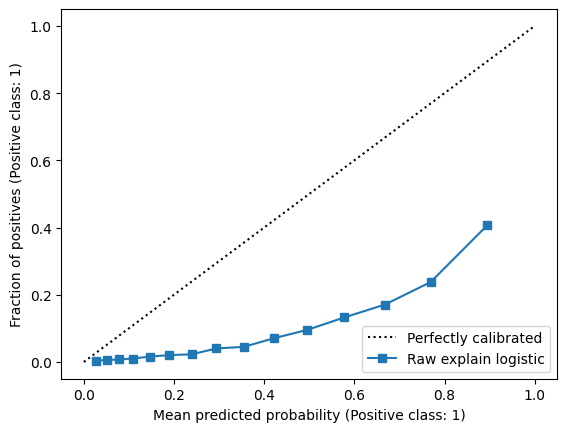

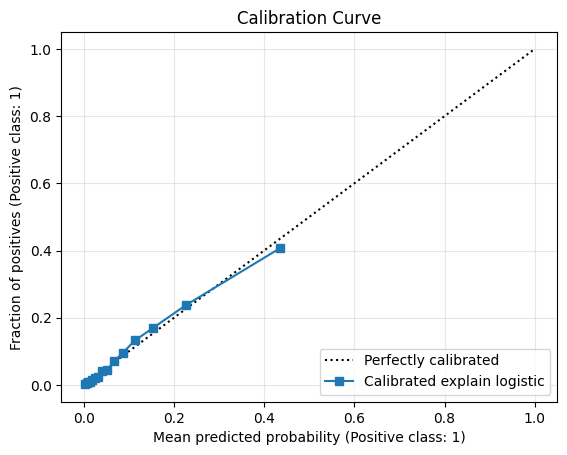


=== Probability result sample ===
   y_true  raw_prob  calibrated_prob
0       0  0.529356         0.096324
1       0  0.520941         0.093664
2       0  0.151793         0.019375
3       0  0.803173         0.257858
4       0  0.169571         0.021813
5       0  0.527458         0.095718
6       0  0.394114         0.060605
7       1  0.593591         0.119288
8       0  0.193443         0.025192
9       0  0.043355         0.005577


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss
)

# =========================================
# 0) 데이터 분리
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # train 60%, calib 20%, test 20%
    stratify=y_train_full,
    random_state=42
)

# =========================================
# 1) 설명용 base logistic (스케일링 X)
# =========================================
explain_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

explain_model.fit(X_train, y_train)

# =========================================
# 2) 계수 / Odds Ratio 확인
# =========================================
coef = explain_model.coef_[0]
odds_ratio = np.exp(coef)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coef,
    "odds_ratio": odds_ratio,
    "abs_coef": np.abs(coef)
})

print("=== Coefficient Table (sorted by abs_coef) ===")
print(coef_df.sort_values("abs_coef", ascending=False))

print("\n=== Odds Ratio Table (descending) ===")
print(coef_df.sort_values("odds_ratio", ascending=False))

# =========================================
# 3) 캘리브레이션
# =========================================
cal_model = CalibratedClassifierCV(
    estimator=explain_model,
    method="sigmoid",
    cv="prefit"
)
cal_model.fit(X_calib, y_calib)

# =========================================
# 4) TEST 확률 평가
# =========================================
test_prob_raw = explain_model.predict_proba(X_test)[:, 1]
test_prob_cal = cal_model.predict_proba(X_test)[:, 1]

print("\n=== Explain/Probability model on TEST ===")
print(f"Raw ROC AUC        : {roc_auc_score(y_test, test_prob_raw):.4f}")
print(f"Raw PR AUC         : {average_precision_score(y_test, test_prob_raw):.4f}")
print(f"Calibrated ROC AUC : {roc_auc_score(y_test, test_prob_cal):.4f}")
print(f"Calibrated PR AUC  : {average_precision_score(y_test, test_prob_cal):.4f}")
print(f"Brier Score        : {brier_score_loss(y_test, test_prob_cal):.4f}")

# =========================================
# 5) Calibration curve 비교
# =========================================
plt.figure(figsize=(6, 6))

CalibrationDisplay.from_predictions(
    y_test,
    test_prob_raw,
    n_bins=15,
    strategy="quantile",
    name="Raw explain logistic"
)

CalibrationDisplay.from_predictions(
    y_test,
    test_prob_cal,
    n_bins=15,
    strategy="quantile",
    name="Calibrated explain logistic"
)

plt.title("Calibration Curve")
plt.grid(alpha=0.3)
plt.show()

# =========================================
# 6) 확률 결과 저장
# =========================================
prob_result_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "raw_prob": test_prob_raw,
    "calibrated_prob": test_prob_cal
})

print("\n=== Probability result sample ===")
print(prob_result_df.head(10))

# 모델 저장

In [53]:
import joblib

model_bundle = {
    "perf_model": perf_model,
    "threshold": best_th,
    "explain_model": explain_model,
    "cal_model": cal_model,
    "features": X.columns.tolist()
}

joblib.dump(model_bundle, "final_models.pkl")

print("모델 저장 완료")

모델 저장 완료
